# World Cup 2026 Prediction Analysis

Objective:
- Inspect the data, features, model metrics, and tournament outputs from this repository in one rerunnable place.
- Keep the analysis time-aware: historical features must use only information available before each match.
- Make it easy to spot probability, Elo, and bracket issues before trusting simulation outputs.

Success criteria:
- Raw data and generated outputs are easy to locate.
- Feature tables and backtests can be rebuilt from local files when present.
- Simulation probabilities can be audited with compact tables and charts.
- Core simulator assumptions are checked directly in the notebook.

In [16]:
from __future__ import annotations

from pathlib import Path
import random
import sys
from typing import Any

import numpy as np
import pandas as pd
import yaml

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists() and (ROOT.parent / "pyproject.toml").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

ROOT

WindowsPath('c:/Users/miqba/projects/ML World Cup Prediction')

## Project Configuration

This section centralizes paths and tournament parameters. Update the candidate filenames if your local raw data uses different names.

In [17]:
CONFIG_DIR = ROOT / "configs"
DATA_DIR = ROOT / "data"
OUTPUTS_DIR = ROOT / "outputs"

with (CONFIG_DIR / "tournament_2026.yaml").open("r", encoding="utf-8") as fh:
    tournament_config = yaml.safe_load(fh)
with (CONFIG_DIR / "data_config.yaml").open("r", encoding="utf-8") as fh:
    data_config = yaml.safe_load(fh)

PRE_TOURNAMENT_CUTOFF = pd.Timestamp(tournament_config.get("data_cutoff", "2026-06-11"))
N_SIMULATIONS = int(tournament_config.get("simulation_count", 10_000))
THIRD_PLACE_QUALIFIERS = int(tournament_config.get("third_place_qualifiers", 8))

paths = {
    "team_mapping": DATA_DIR / "external" / "team_mapping.csv",
    "raw_matches_candidates": [
        DATA_DIR / "raw" / "results.csv",
        DATA_DIR / "raw" / "matches.csv",
        DATA_DIR / "raw" / "international_matches.csv",
    ],
    "raw_rankings_candidates": [
        DATA_DIR / "raw" / "fifa_ranking.csv",
        DATA_DIR / "raw" / "rankings.csv",
        DATA_DIR / "raw" / "fifa_rankings.csv",
    ],
    "simulation_output": OUTPUTS_DIR / "simulations" / "team_probabilities_2026.csv",
    "backtest_output": OUTPUTS_DIR / "backtest_results" / "model_backtest.csv",
}

tournament_config, data_config

({'name': 'FIFA World Cup 2026',
  'mode': 'pre_tournament',
  'data_cutoff': '2026-06-11',
  'group_count': 12,
  'teams_per_group': 4,
  'third_place_qualifiers': 8,
  'simulation_count': 10000,
  'simulation_predictor': 'elo_baseline',
  'draw_probability': 0.24,
  'groups': {'A': ['Mexico', 'South Africa', 'South Korea', 'Czechia'],
   'B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
   'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
   'D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
   'E': ['Germany', 'Curacao', 'Ivory Coast', 'Ecuador'],
   'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
   'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
   'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
   'I': ['France', 'Senegal', 'Iraq', 'Norway'],
   'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
   'K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
   'L': ['England', 'Croatia', 'Ghana', 'Panama']},
  'ranking_tiebreakers': ['points',

In [18]:
def first_existing(candidates: list[Path]) -> Path | None:
    return next((path for path in candidates if path.exists()), None)


def read_csv_if_exists(path: Path | None, **kwargs: Any) -> pd.DataFrame | None:
    if path is None or not path.exists():
        return None
    return pd.read_csv(path, **kwargs)


def file_status(path: Path) -> dict[str, Any]:
    return {
        "path": str(path.relative_to(ROOT)) if path.exists() or ROOT in path.parents else str(path),
        "exists": path.exists(),
        "size_kb": round(path.stat().st_size / 1024, 1) if path.exists() else np.nan,
    }

inventory_rows = [file_status(paths["team_mapping"])]
inventory_rows += [file_status(path) for path in paths["raw_matches_candidates"]]
inventory_rows += [file_status(path) for path in paths["raw_rankings_candidates"]]
inventory_rows += [file_status(paths["simulation_output"]), file_status(paths["backtest_output"])]

pd.DataFrame(inventory_rows)

,path,exists,size_kb
0,data\external\team_mapping.csv,True,0.3
1,data\raw\results.csv,False,NaN
2,data\raw\matches.csv,False,NaN
3,data\raw\international_matches.csv,True,3681.4
4,data\raw\fifa_ranking.csv,False,NaN
5,data\raw\rankings.csv,False,NaN
6,data\raw\fifa_rankings.csv,True,2059.7
7,outputs\simulations\team_probabilities_2026.csv,True,3.1
8,outputs\backtest_results\model_backtest.csv,True,1.0


## Load And Clean Inputs

The notebook can run before raw data exists. If files are missing, later cells skip rebuild steps and still let you inspect generated outputs.

In [19]:
from worldcup_prediction.cleaning import clean_matches, clean_rankings
from worldcup_prediction.elo import add_elo_features, default_k_factor
from worldcup_prediction.features import build_feature_table
from worldcup_prediction.models import DEFAULT_FEATURE_COLUMNS, make_model, train_model, predict_probabilities
from worldcup_prediction.backtest import rolling_world_cup_backtest
from worldcup_prediction.metrics import evaluate_probabilities
from worldcup_prediction.simulator import (
    normalize_match_probabilities,
    pair_seeded_qualifiers,
    pair_bracket_winners,
    simulate_tournament,
)

team_mapping = None
if paths["team_mapping"].exists():
    mapping_frame = pd.read_csv(paths["team_mapping"])
    team_mapping = dict(zip(mapping_frame["raw_team_name"], mapping_frame["standard_team_name"], strict=False))

matches_path = first_existing(paths["raw_matches_candidates"])
rankings_path = first_existing(paths["raw_rankings_candidates"])
raw_matches = read_csv_if_exists(matches_path)
raw_rankings = read_csv_if_exists(rankings_path)

{
    "matches_path": str(matches_path.relative_to(ROOT)) if matches_path else None,
    "rankings_path": str(rankings_path.relative_to(ROOT)) if rankings_path else None,
    "team_mapping_entries": 0 if team_mapping is None else len(team_mapping),
    "raw_matches_rows": None if raw_matches is None else len(raw_matches),
    "raw_rankings_rows": None if raw_rankings is None else len(raw_rankings),
}

{'matches_path': 'data\\raw\\international_matches.csv',
 'rankings_path': 'data\\raw\\fifa_rankings.csv',
 'team_mapping_entries': 12,
 'raw_matches_rows': 49425,
 'raw_rankings_rows': 67883}

In [20]:
if raw_matches is not None:
    matches = clean_matches(raw_matches, team_mapping)
    matches = add_elo_features(matches)
    display(matches.head())
    display(
        pd.DataFrame(
            {
                "matches": [len(matches)],
                "min_date": [matches["date"].min()],
                "max_date": [matches["date"].max()],
                "teams": [pd.concat([matches["team_a"], matches["team_b"]]).nunique()],
                "tournaments": [matches["tournament"].nunique()],
            }
        )
    )
else:
    matches = None
    print("No raw match file found. Add a CSV under data/raw to rebuild features in this notebook.")

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,team_a,team_b,team_a_score,team_b_score,stage,group,match_id,team_a_elo,team_b_elo,elo_diff,elo_avg,elo_abs_diff
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,Scotland,England,0,0,,,49baae76c645f88f,1500.000000,1500.000000,0.000000,1500.0,0.000000
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,England,Scotland,4,2,,,e30c27ff35450826,1500.000000,1500.000000,0.000000,1500.0,0.000000
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,Scotland,England,2,1,,,2cb07422f497b79b,1490.000000,1510.000000,-20.000000,1500.0,20.000000
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,England,Scotland,2,2,,,8cf8ec4ac6ff3372,1499.424989,1500.575011,-1.150023,1500.0,1.150023
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,Scotland,England,3,0,,,91ec85536568d0bd,1500.541911,1499.458089,1.083822,1500.0,1.083822


,matches,min_date,max_date,teams,tournaments
0,49424,1872-11-30,2026-06-16,336,200


In [21]:
if raw_rankings is not None:
    rankings = clean_rankings(raw_rankings, team_mapping)
    display(rankings.head())
    display(
        pd.DataFrame(
            {
                "rankings": [len(rankings)],
                "min_rank_date": [rankings["rank_date"].min()],
                "max_rank_date": [rankings["rank_date"].max()],
                "ranked_teams": [rankings["team"].nunique()],
            }
        )
    )
else:
    rankings = None
    print("No FIFA ranking file found. Feature rebuilds will continue without ranking columns if match data exists.")

,rank_date,team,rank,points
0,2003-01-15,Afghanistan,203,7.0
1,2003-02-19,Afghanistan,202,9.0
2,2003-03-26,Afghanistan,197,48.0
3,2003-04-23,Afghanistan,197,48.0
4,2003-05-21,Afghanistan,198,48.0


,rankings,min_rank_date,max_rank_date,ranked_teams
0,67883,1992-12-31,2024-09-19,227


## Feature Table And Leakage Checks

The key check is that pre-tournament analysis uses a cutoff before the first 2026 match. For live analysis, change the cutoff deliberately and record it here.

In [22]:
if matches is not None:
    features = build_feature_table(matches, rankings)
    feature_summary = pd.DataFrame(
        {
            "rows": [len(features)],
            "min_date": [features["date"].min()],
            "max_date": [features["date"].max()],
            "pre_cutoff_rows": [int((features["date"] < PRE_TOURNAMENT_CUTOFF).sum())],
            "post_cutoff_rows": [int((features["date"] >= PRE_TOURNAMENT_CUTOFF).sum())],
            "target_values": [sorted(features["target"].dropna().unique().tolist())],
        }
    )
    display(feature_summary)
    display(features[DEFAULT_FEATURE_COLUMNS + ["target", "date", "tournament"]].head())
else:
    features = None
    print("Skipping feature build because match data is unavailable.")

,rows,min_date,max_date,pre_cutoff_rows,post_cutoff_rows,target_values
0,49424,1872-11-30,2026-06-16,49404,20,"[0, 1, 2]"


,elo_diff,fifa_rank_diff,fifa_points_diff,form_points_diff_5,form_points_diff_10,goal_diff_form_10,is_neutral,is_world_cup,rest_days_diff,target,date,tournament
0,0.000000,NaN,NaN,NaN,NaN,NaN,0,0,NaN,1,1872-11-30,Friendly
1,0.000000,NaN,NaN,0.0,0.0,0.000000,0,0,0.0,2,1873-03-08,Friendly
2,-20.000000,NaN,NaN,-1.5,-1.5,-2.000000,0,0,0.0,2,1874-03-07,Friendly
3,-1.150023,NaN,NaN,0.0,0.0,0.666667,0,0,0.0,1,1875-03-06,Friendly
4,1.083822,NaN,NaN,0.0,0.0,-0.500000,0,0,0.0,2,1876-03-04,Friendly


In [23]:
if features is not None:
    missing_rates = (
        features[DEFAULT_FEATURE_COLUMNS]
        .isna()
        .mean()
        .sort_values(ascending=False)
        .rename("missing_rate")
        .to_frame()
    )
    target_distribution = features["target"].value_counts(normalize=True).rename_axis("target").reset_index(name="share")
    display(missing_rates)
    display(target_distribution)
else:
    print("No feature diagnostics to show yet.")

,missing_rate
fifa_rank_diff,0.45830
fifa_points_diff,0.45830
goal_diff_form_10,0.00611
form_points_diff_5,0.00611
form_points_diff_10,0.00611
rest_days_diff,0.00611
elo_diff,0.00000
is_neutral,0.00000
is_world_cup,0.00000


,target,share
0,2,0.490066
1,0,0.282494
2,1,0.227440


## Rolling World Cup Backtest

This rebuilds time-aware World Cup validation windows. The model trains only on matches before each tournament window.

In [24]:
if features is not None:
    available_feature_columns = [column for column in DEFAULT_FEATURE_COLUMNS if column in features.columns]
    backtest = rolling_world_cup_backtest(
        features,
        model_factory=lambda: make_model("logistic", random_state=SEED),
        feature_columns=available_feature_columns,
    )
    if backtest.empty:
        print("No complete World Cup backtest windows found in the current local data.")
    else:
        display(backtest)
        display(backtest.select_dtypes(include="number").describe().T)
else:
    backtest = None
    print("Skipping backtest because features are unavailable.")

,year,train_matches,test_matches,log_loss,brier_score,accuracy,top1_accuracy
0,2002,26436,64,1.061643,0.629099,0.531250,0.531250
1,2006,30037,64,0.944700,0.560014,0.578125,0.578125
2,2010,33864,64,0.987769,0.587648,0.531250,0.531250
3,2014,37861,64,0.974219,0.584689,0.500000,0.500000
4,2018,41639,64,0.982761,0.585026,0.546875,0.546875
5,2022,45700,64,1.094947,0.631831,0.531250,0.531250


,count,mean,std,min,25%,50%,75%,max
year,6.0,2012.000000,7.483315,2002.000000,2007.000000,2012.000000,2017.000000,2022.000000
train_matches,6.0,35922.833333,7223.653852,26436.000000,30993.750000,35862.500000,40694.500000,45700.000000
test_matches,6.0,64.000000,0.000000,64.000000,64.000000,64.000000,64.000000,64.000000
log_loss,6.0,1.007673,0.057674,0.944700,0.976354,0.985265,1.043174,1.094947
brier_score,6.0,0.596385,0.028255,0.560014,0.584774,0.586337,0.618736,0.631831
accuracy,6.0,0.536458,0.025516,0.500000,0.531250,0.531250,0.542969,0.578125
top1_accuracy,6.0,0.536458,0.025516,0.500000,0.531250,0.531250,0.542969,0.578125


In [25]:
existing_backtest = read_csv_if_exists(paths["backtest_output"])
if existing_backtest is not None:
    display(existing_backtest)
else:
    print("No generated backtest output found at outputs/backtest_results/model_backtest.csv.")

,model,year,train_matches,test_matches,log_loss,brier_score,accuracy,top1_accuracy
0,logistic,2002,26436,64,1.061643,0.629099,0.531250,0.531250
1,logistic,2006,30037,64,0.944700,0.560014,0.578125,0.578125
2,logistic,2010,33864,64,0.987769,0.587648,0.531250,0.531250
3,logistic,2014,37861,64,0.974219,0.584689,0.500000,0.500000
4,logistic,2018,41639,64,0.982761,0.585026,0.546875,0.546875
5,logistic,2022,45700,64,1.094947,0.631831,0.531250,0.531250
6,random_forest,2002,26436,64,1.025450,0.604132,0.515625,0.515625
7,random_forest,2006,30037,64,0.918393,0.542960,0.625000,0.625000
8,random_forest,2010,33864,64,0.992841,0.587461,0.515625,0.515625
9,random_forest,2014,37861,64,0.984672,0.595824,0.546875,0.546875


## Train A Pre-Tournament Baseline

This section trains a compact baseline on rows before the configured cutoff. It is useful for inspecting model probability behavior before wiring future fixture generation.

In [26]:
if features is not None:
    train_frame = features[features["date"] < PRE_TOURNAMENT_CUTOFF].copy()
    feature_columns = [column for column in DEFAULT_FEATURE_COLUMNS if column in train_frame.columns]
    if train_frame.empty:
        model = None
        print("No training rows before cutoff.")
    else:
        model = train_model(make_model("logistic", random_state=SEED), train_frame, feature_columns)
        train_probabilities = predict_probabilities(model, train_frame.tail(min(500, len(train_frame))), feature_columns)
        train_metrics = evaluate_probabilities(train_frame.tail(len(train_probabilities))["target"], train_probabilities)
        display(pd.DataFrame([train_metrics]))
        display(train_probabilities.head())
else:
    model = None
    print("Skipping baseline training because features are unavailable.")

,log_loss,brier_score,accuracy,top1_accuracy
0,0.905222,0.535525,0.58,0.58


,team_a_loss,draw,team_a_win
48904,0.124459,0.318943,0.556598
48905,0.587920,0.311668,0.100412
48906,0.359772,0.395380,0.244848
48907,0.170465,0.353133,0.476401
48908,0.085388,0.279536,0.635076


## Tournament Simulation Outputs

Use this section after generating `outputs/simulations/team_probabilities_2026.csv`. The expected columns are team-level milestone probabilities such as `advance_from_group`, `reach_final`, and `champion`.

In [27]:
simulation_output = read_csv_if_exists(paths["simulation_output"])
if simulation_output is not None:
    probability_columns = [column for column in simulation_output.columns if column != "team"]
    display(simulation_output.sort_values("champion", ascending=False).head(20))
    display(simulation_output[probability_columns].describe().T)
else:
    print("No simulation output found at outputs/simulations/team_probabilities_2026.csv.")

,team,group_win,advance_from_group,reach_r32,reach_r16,reach_qf,reach_sf,reach_final,champion
0,Spain,0.6467,0.9623,0.9623,0.6428,0.4448,0.3132,0.2068,0.1309
1,Argentina,0.6082,0.9384,0.9384,0.6114,0.4333,0.2955,0.1901,0.1223
2,France,0.5318,0.9078,0.9078,0.6064,0.3923,0.2434,0.1384,0.0832
3,England,0.4918,0.9038,0.9038,0.5613,0.3298,0.1956,0.1070,0.0555
4,Brazil,0.4332,0.8844,0.8844,0.5159,0.3093,0.1709,0.0932,0.0497
5,Germany,0.4596,0.8967,0.8967,0.5608,0.3138,0.1786,0.0934,0.0483
6,Portugal,0.4174,0.8643,0.8643,0.5246,0.2993,0.1660,0.0911,0.0473
7,Colombia,0.3840,0.8406,0.8406,0.4913,0.2824,0.1464,0.0779,0.0416
8,Morocco,0.3862,0.8633,0.8633,0.4704,0.2710,0.1511,0.0760,0.0392
9,Netherlands,0.4056,0.8531,0.8531,0.4730,0.2802,0.1504,0.0751,0.0371


,count,mean,std,min,25%,50%,75%,max
group_win,48.0,0.250000,0.165768,0.0248,0.099650,0.19595,0.389475,0.6467
advance_from_group,48.0,0.666667,0.200677,0.2286,0.498700,0.66855,0.851675,0.9623
reach_r32,48.0,0.666667,0.200677,0.2286,0.498700,0.66855,0.851675,0.9623
reach_r16,48.0,0.333333,0.164684,0.0519,0.161200,0.33085,0.471050,0.6428
reach_qf,48.0,0.166667,0.114603,0.0130,0.057350,0.15190,0.253775,0.4448
reach_sf,48.0,0.083333,0.075740,0.0031,0.018475,0.06470,0.128800,0.3132
reach_final,48.0,0.041667,0.047041,0.0009,0.005125,0.02760,0.060600,0.2068
champion,48.0,0.020833,0.028985,0.0000,0.001450,0.01050,0.027325,0.1309


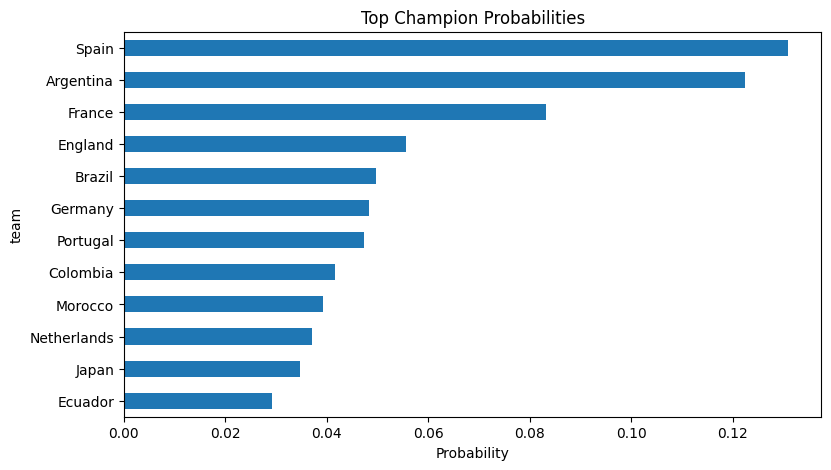

In [28]:
if simulation_output is not None and {"team", "champion"}.issubset(simulation_output.columns):
    top_champions = simulation_output.nlargest(12, "champion").set_index("team")["champion"]
    ax = top_champions.sort_values().plot(kind="barh", figsize=(9, 5), title="Top Champion Probabilities")
    ax.set_xlabel("Probability")
else:
    print("Skipping champion probability chart until simulation output exists.")

## Simulator Assumption Checks

These quick checks cover the assumptions that most directly affect tournament probabilities: probability column aliases, Elo K-factors, and fixed knockout bracket progression.

In [29]:
probability_alias_check = normalize_match_probabilities(
    {"team_a_loss": 0.30, "draw": 0.20, "team_a_win": 0.50}
)

k_factor_check = {
    "world_cup_qualification_first_round": default_k_factor("FIFA World Cup qualification", "First round"),
    "world_cup_qualification_no_stage": default_k_factor("FIFA World Cup qualification", None),
    "world_cup_semifinal": default_k_factor("FIFA World Cup", "Semi-finals"),
    "world_cup_final": default_k_factor("FIFA World Cup", "Final"),
}

bracket_check = {
    "initial_seeded_pairs": pair_seeded_qualifiers(["A1", "A2", "B1", "B2"]),
    "next_round_pairs": pair_bracket_winners(["A1", "A2", "B1", "B2"]),
}

probability_alias_check, k_factor_check, bracket_check

({'team_a_win': 0.5, 'draw': 0.2, 'team_b_win': 0.3},
 {'world_cup_qualification_first_round': 30.0,
  'world_cup_qualification_no_stage': 30.0,
  'world_cup_semifinal': 60.0,
  'world_cup_final': 70.0},
 {'initial_seeded_pairs': [('A1', 'B2'), ('A2', 'B1')],
  'next_round_pairs': [('A1', 'A2'), ('B1', 'B2')]})

In [30]:
toy_groups = {group: [f"{group}{index}" for index in range(1, 5)] for group in ["A", "B", "C", "D"]}

def deterministic_team_a_predictor(team_a: str, team_b: str, context: dict | None = None) -> dict[str, float]:
    return {"team_a_win": 1.0, "draw": 0.0, "team_b_win": 0.0}

toy_simulation = simulate_tournament(
    toy_groups,
    deterministic_team_a_predictor,
    n_simulations=1,
    seed=SEED,
    third_place_count=0,
)

toy_simulation.sort_values("champion", ascending=False).head(8)

,team,group_win,advance_from_group,reach_r32,reach_r16,reach_qf,reach_sf,reach_final,champion
0,A1,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
1,A2,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
2,A3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,A4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,B1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
5,B2,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
6,B3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,B4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Analysis Notes

Use this space to capture decisions from each run.

- Data cutoff used:
- Model family:
- Feature columns included:
- Backtest result worth tracking:
- Simulation output version:
- Follow-up checks: